In [29]:
import os
import sys
import json
import numpy as np
import torch as th
import matplotlib.pyplot as plt
import motornet as mn
from utils import run_rollout, plot_simulations
from importlib import reload
import agents
import utils
reload(utils)
reload(agents)
from agents import SLAgent
from tasks import CentreOutFF

# from sklearn.decomposition import PCA

Using device: cpu


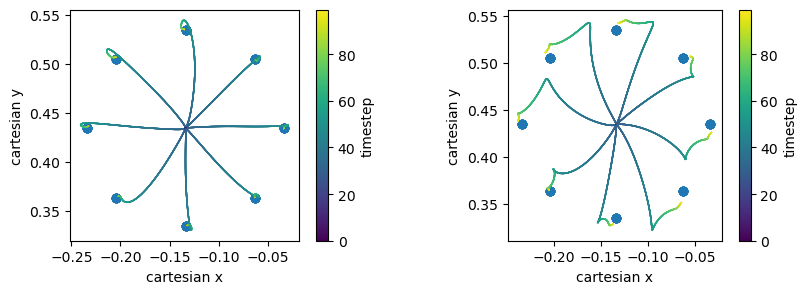

<Figure size 1000x300 with 0 Axes>

In [32]:
# --- device setting and config loading ---
device = th.device("cuda" if th.cuda.is_available() else "cpu")
config = 'params.json'
print(f"Using device: {device}")
with open(config, 'r') as f:
    config = json.load(f)

n_obs, n_actions = 17, 6

# --- parameters setting ---
env_params = config['env_params']
train_params = config['training_params']
effector = mn.effector.RigidTendonArm26(muscle=mn.muscle.RigidTendonHillMuscle())
env = CentreOutFF(effector=effector, **env_params)
agentSL = SLAgent(n_obs, n_actions)

agentSL.load('agent_baseline_18000.pth')
fig, axes = plt.subplots(1, 2, figsize=(10,3))
data = run_rollout(env, agentSL, batch_size = 64, condition='test',ff_coefficient = 0., catch_trial_perc=0.0)
plt.figure(figsize=(10,3))
plot_simulations(data, axes[0])
data = run_rollout(env, agentSL, batch_size = 64, condition='test',ff_coefficient = 8., catch_trial_perc=0.0)
plot_simulations(data, axes[1])

